In [1]:
%load_ext autoreload
%autoreload 2

# `import`

In [3]:
import random

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from dice_rl_TU_Vienna.latex import latex_labels
from dice_rl_TU_Vienna.plot.continuous import get_log

from dice_rl_TU_Vienna.estimators.get import get_pv_s
from dice_rl_TU_Vienna.estimators.onpolicy import OnPE
from dice_rl_TU_Vienna.estimators.tabular.tabular_OffPE         import AuxiliaryEstimates
from dice_rl_TU_Vienna.estimators.tabular.tabular_vafe          import TabularVafe
from dice_rl_TU_Vienna.estimators.tabular.tabular_dice          import TabularDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice     import TabularDualDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice import TabularGradientDice

from dice_rl_TU_Vienna.utils.general import flatten_dict, dict_to_str
from dice_rl_TU_Vienna.utils.numpy import moving_average_N
from dice_rl_TU_Vienna.utils.json import json_get_id

from plugins.sepsis.bologheanu.tabular.config import n_obs
from plugins.sepsis.bologheanu.continuous.plot import get_logs_and_plot
from plugins.sepsis.bologheanu.continuous.config import *

# Prepare

In [21]:
estimators = { "behavior": OnPE(dataset["neural"]), }

get_policy_value_behavior = lambda gamma, scale=False: estimators["behavior"].solve(gamma, scale=scale)[0]

get_policy_value = { "behavior": get_policy_value_behavior, }

In [5]:
names = [
    "NeuralGradientDice",
    "NeuralGenDice",
]

lrs = {
    "NeuralGradientDice": 1e-3,
    "NeuralGenDice": 1e-4,
}

others = {
    "NeuralGradientDice": {"lamda": lamda},
    "NeuralGenDice": {"lamda": lamda},
}

axvspans = [
    {
        "NeuralGradientDice": (200_000, 1_000_000),
        "NeuralGenDice": (200_000, 1_000_000),
    },
    {
        "NeuralGradientDice": (100_000, 225_000),
        "NeuralGenDice": (600_000, 1_000_000),
    },
    {
        "NeuralGradientDice": (300_000, 600_000),
        "NeuralGenDice": (600_000, 1_000_000),
    },
    {
        "NeuralGradientDice": (80_000, 100_000),
        "NeuralGenDice": (600_00, 900_000),
    },
]

n_ma = 128

# Selected Plots

In [6]:
def plot_single(
        name, learning_rate, hidden_dimensions, other,
        xlim=None, ylim1=None, ylim2=None, yscale=False, axvspan=None
    ):

    hyperparameters = {
        "name": name,
        "gamma": gamma,
        "seed": seed,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "hidden_dimensions": hidden_dimensions,
        "other": other,
    }

    id_evaluation = json_get_id(
        file_path=os.path.join(dir_dataset["continuous"]["neural"], "evaluation.json"),
        dictionary=hyperparameters
    )

    log = get_log(
        log_dir=os.path.join(dir_dataset["continuous"]["neural"], id_evaluation), ) # type: ignore

    _, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(20, 5), tight_layout=True)

    y = get_policy_value["behavior"](gamma, scale=False)
    ax1.axhline(y=y, label="OnPE behavior", color="black", linestyle=":")

    x = np.array(log["data"]["pv_s"]["steps"])
    y = np.array(log["data"]["pv_s"]["values"]) / (1 - gamma)
    if yscale: ax1.semilogy(x, y, label="simple")
    else:      ax1.plot    (x, y, label="simple")

    x = np.array(log["data"]["pv_w"]["steps"])
    y = np.array(log["data"]["pv_w"]["values"]) / (1 - gamma)
    if yscale: ax1.semilogy(x, y, label="weighted")
    else:      ax1.plot    (x, y, label="weighted")

    x = np.array(log["data"]["loss"]["steps"])
    y = np.array(log["data"]["loss"]["values"])
    ax2.plot(x, y, color="black")

    x = np.array(log["data"]["cos_angle"]["steps"])
    y = np.array(log["data"]["cos_angle"]["values"])
    y = np.arccos(y)
    ax3.plot(x, y, color="black")

    ax1.set_ylabel( latex_labels["pv_scaled"]() )
    ax2.set_ylabel( latex_labels["loss"]("") )
    ax3.set_ylabel( r"$\measuredangle ( \nabla P^\pi v, \nabla v )$" )

    ax3.set_yticks(      [ 0,      1/16 * np.pi,        1/8 * np.pi,        3/16 * np.pi,           ] )
    ax3.set_yticklabels( [ r"$0$", r"$\frac{\pi}{16}$", r"$\frac{\pi}{8}$", r"$\frac{ 3 \pi}{16}$", ] )


    if xlim is not None:
        ax1.set_xlim(xlim)
        ax2.set_xlim(xlim)
    if ylim1 is not None: ax1.set_ylim(ylim1)
    if ylim2 is not None: ax2.set_ylim(ylim2)

    if axvspan is not None:
        ax1.axvspan(*axvspan, color="black", alpha=0.1)
        ax2.axvspan(*axvspan, color="black", alpha=0.1)
        ax3.axvspan(*axvspan, color="black", alpha=0.1)

    suptitle = "Sepsis Bologheanu Continuous" + "\n" + dict_to_str( flatten_dict(hyperparameters) )
    plt.suptitle(suptitle)

    plt.xlabel("step")

    ax1.legend()

    ax1.grid(linestyle=":")
    ax2.grid(linestyle=":")
    ax3.grid(linestyle=":")

    file_name = suptitle.replace("\n", "; ")
    path = os.path.join(dir_images, "continuous", f"{file_name}.png")
    plt.savefig(path)

    plt.show()

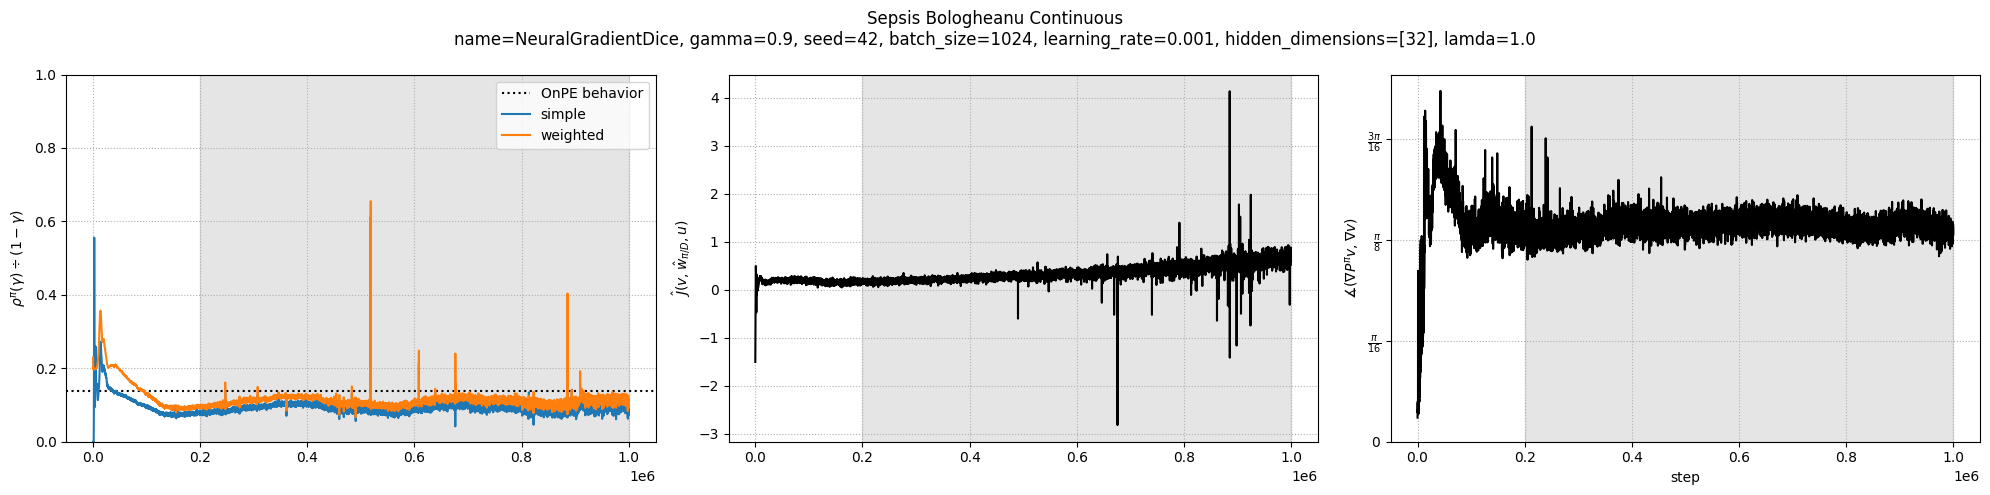

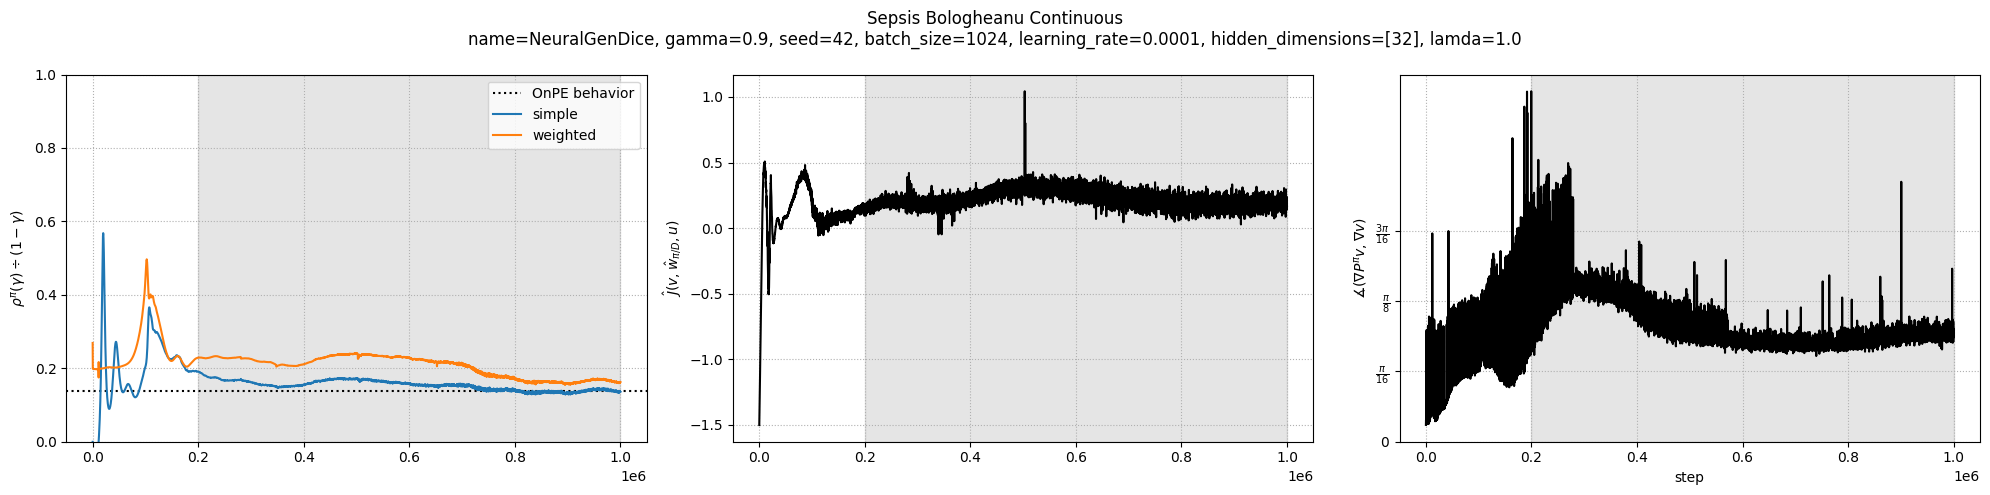

# ---------------------------------------------------------------- # 



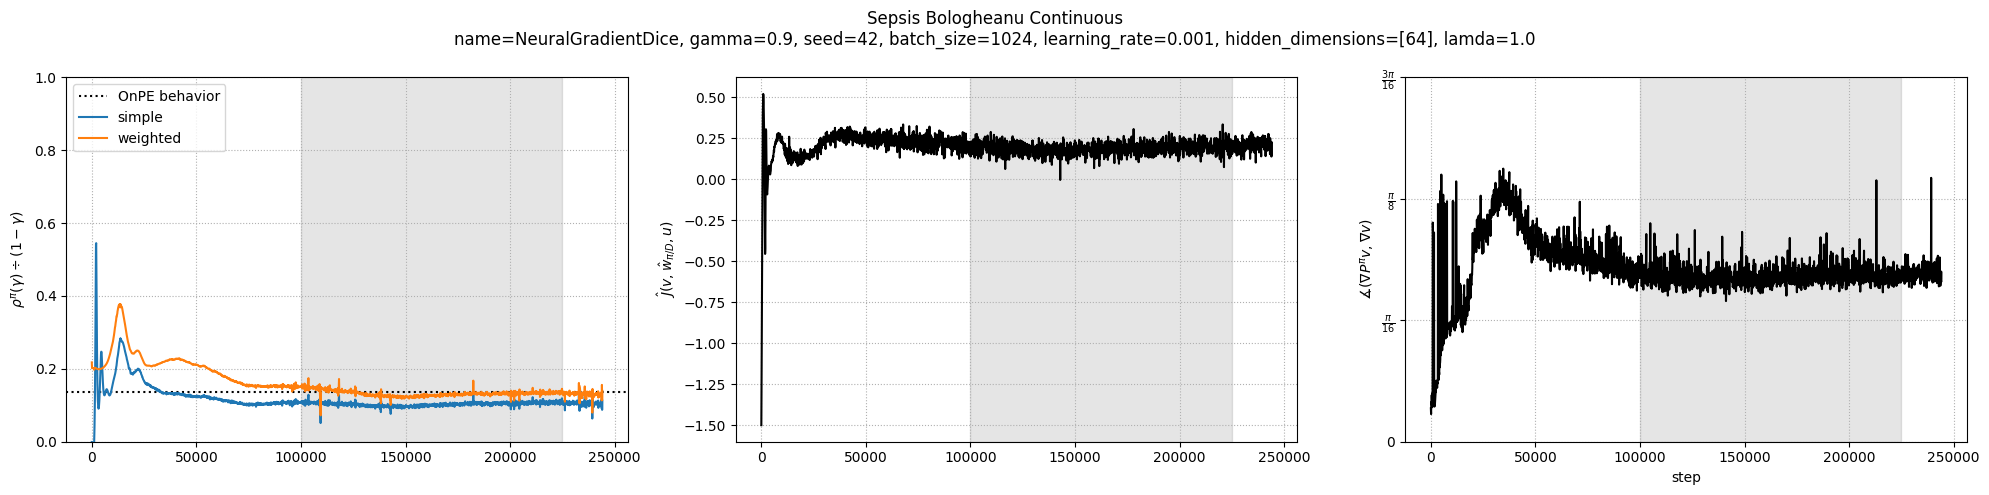

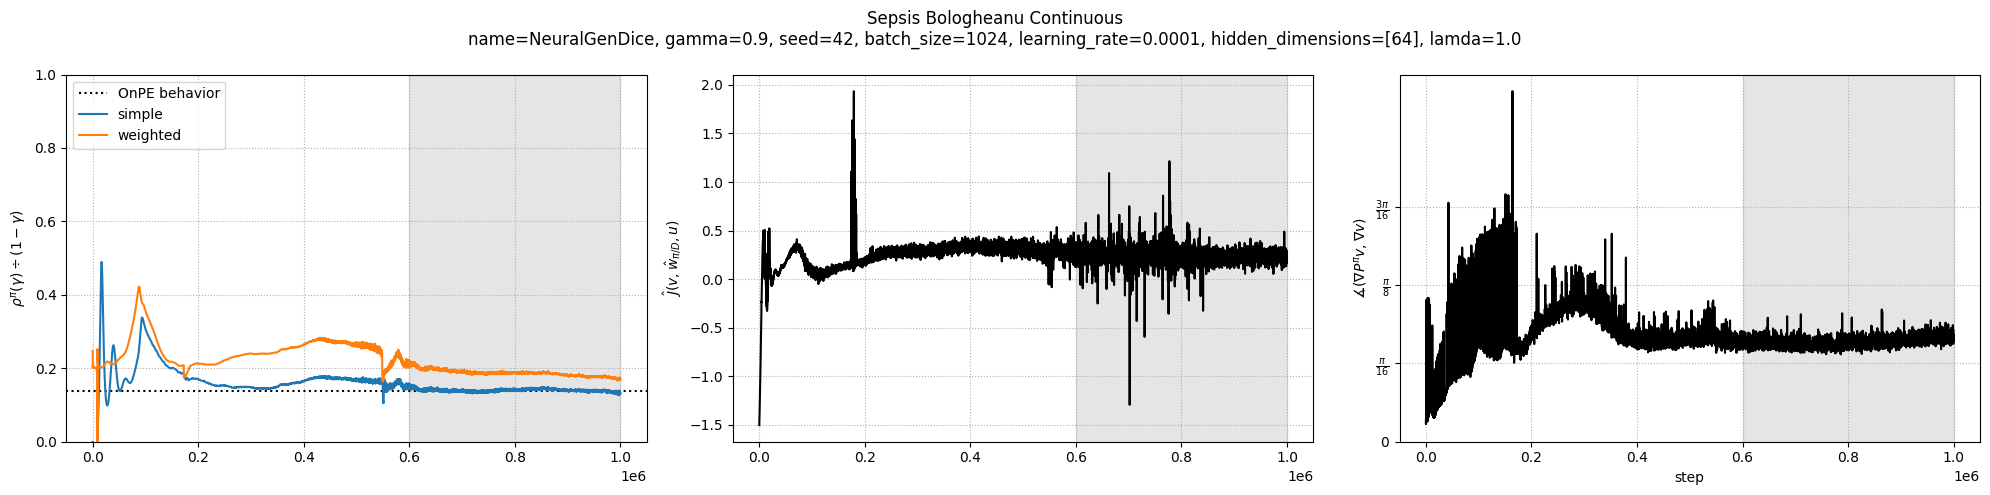

# ---------------------------------------------------------------- # 



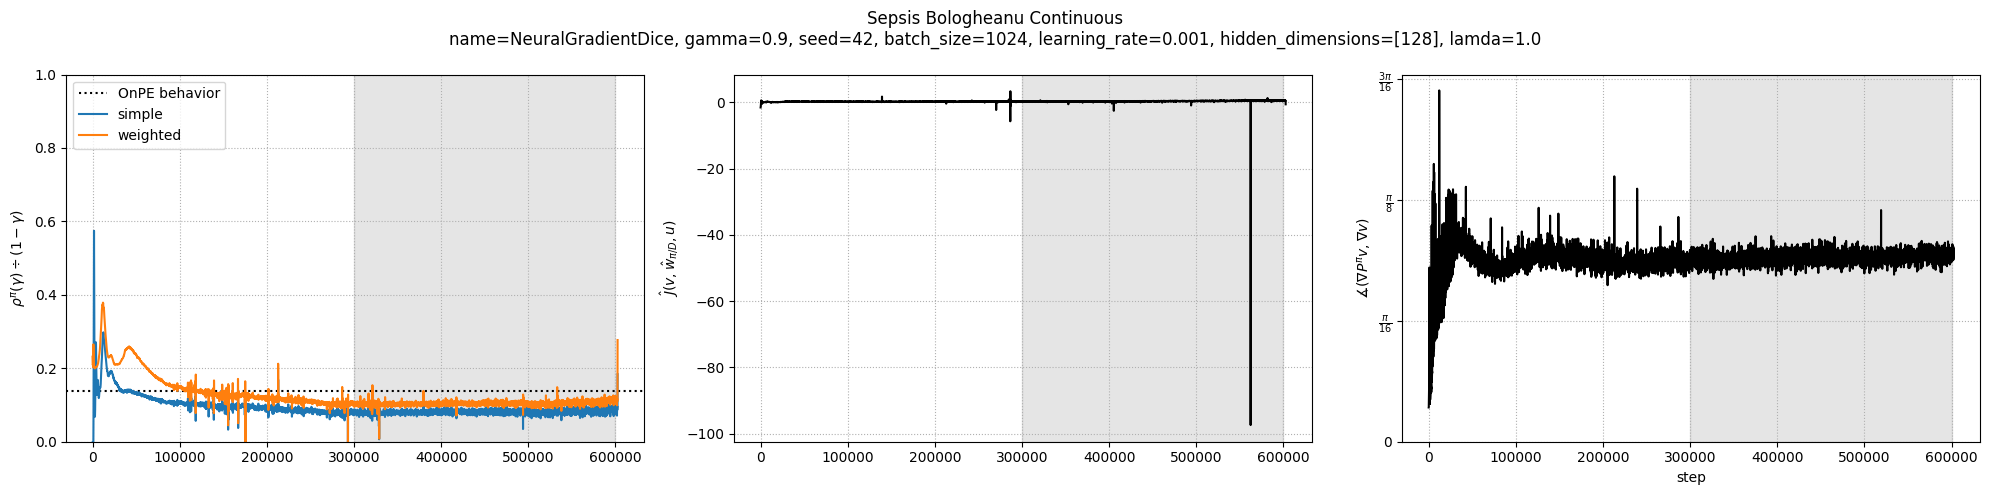

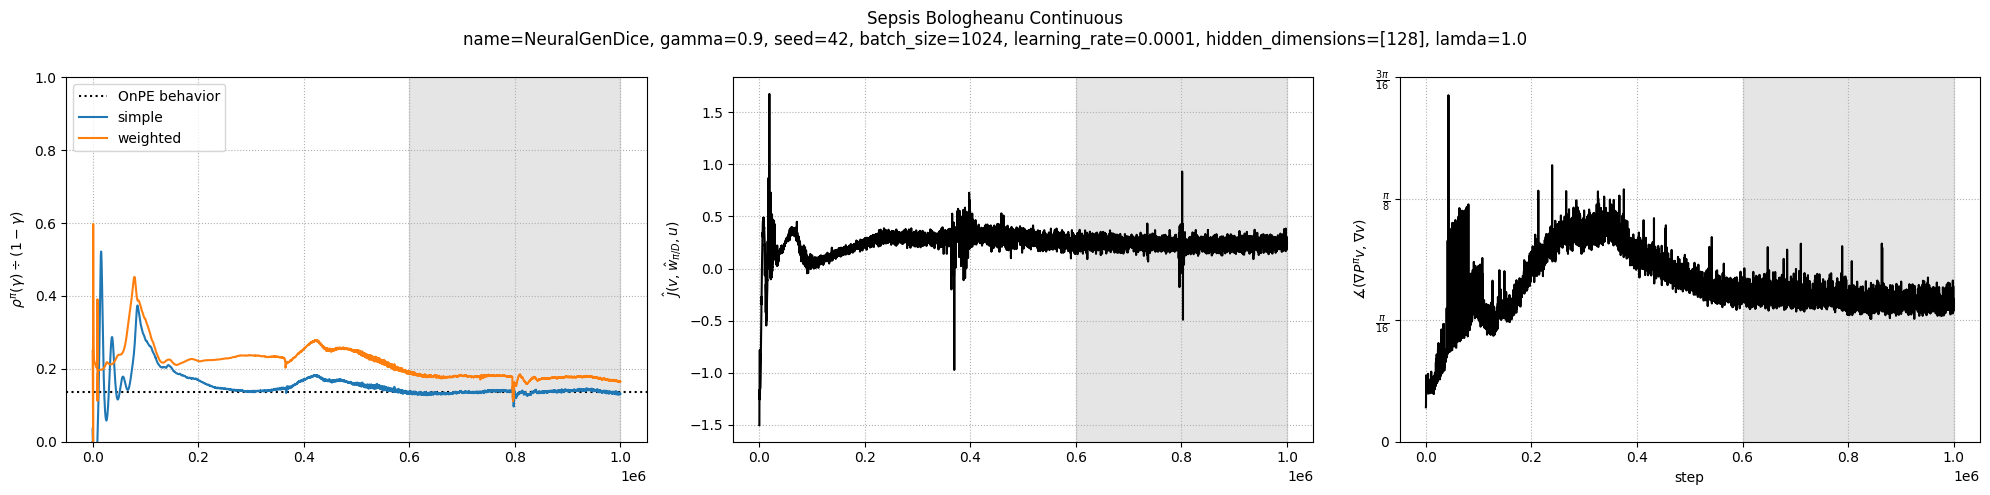

# ---------------------------------------------------------------- # 



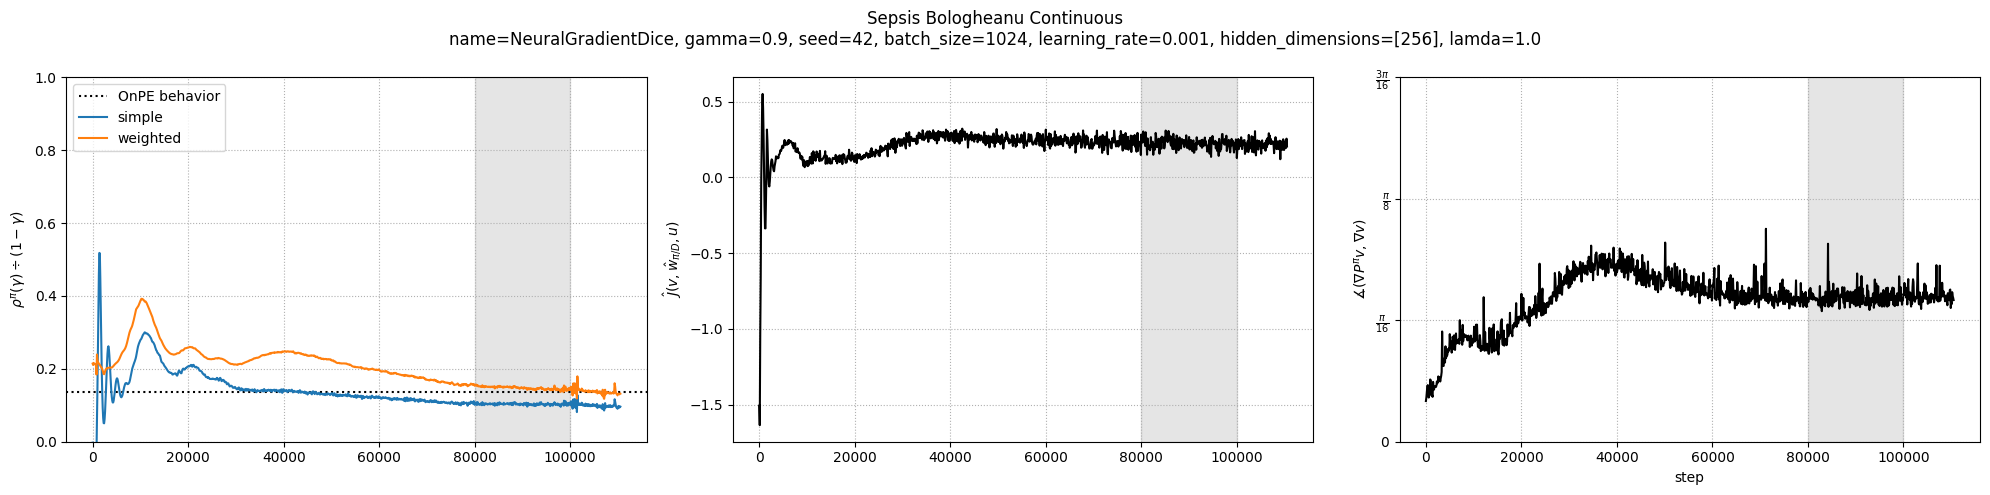

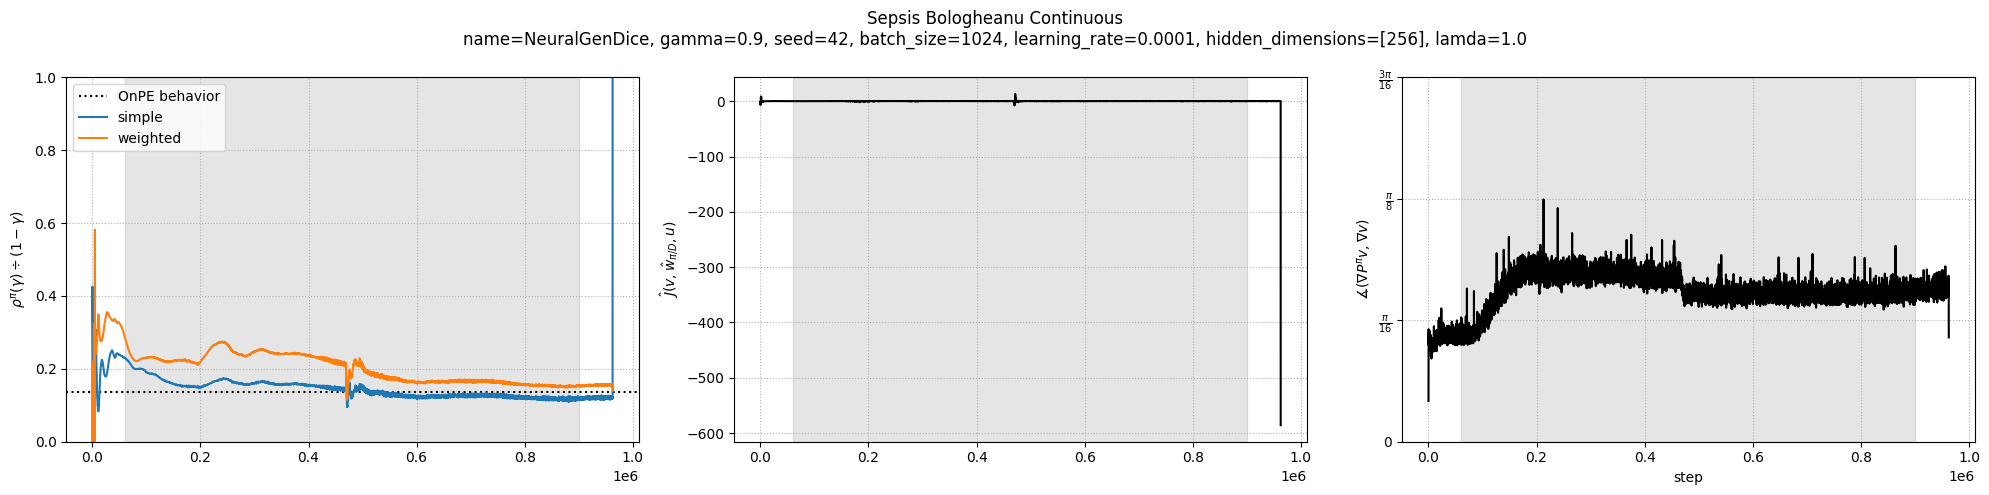

# ---------------------------------------------------------------- # 



In [8]:
for hidden_dimensions, axvspan in zip(hidden_dimensionss, axvspans):

    plot_single("NeuralGradientDice", lrs["NeuralGradientDice"], hidden_dimensions, {"lamda": lamda}, ylim1=(0, 1), ylim2=None, axvspan=axvspan["NeuralGradientDice"])
    plot_single("NeuralGenDice",      lrs["NeuralGenDice"],      hidden_dimensions, {"lamda": lamda}, ylim1=(0, 1), ylim2=None, axvspan=axvspan["NeuralGenDice"])

    print("#", "-"*64, "#", "\n")

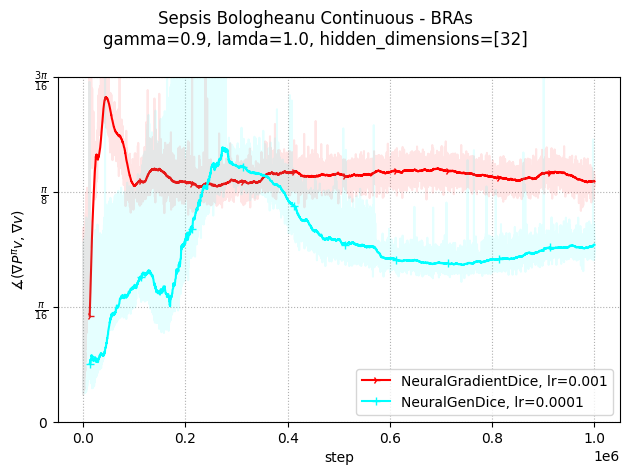

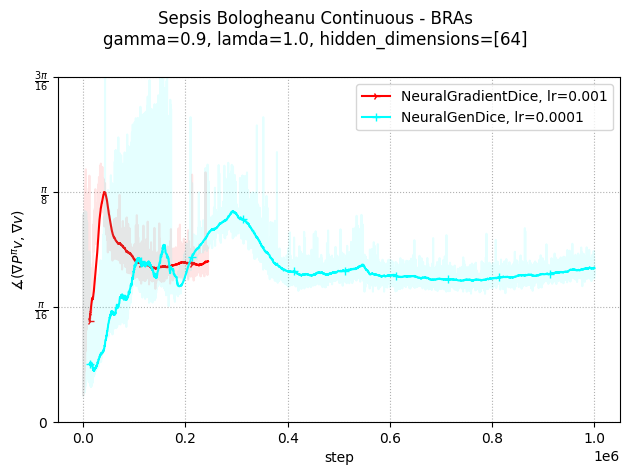

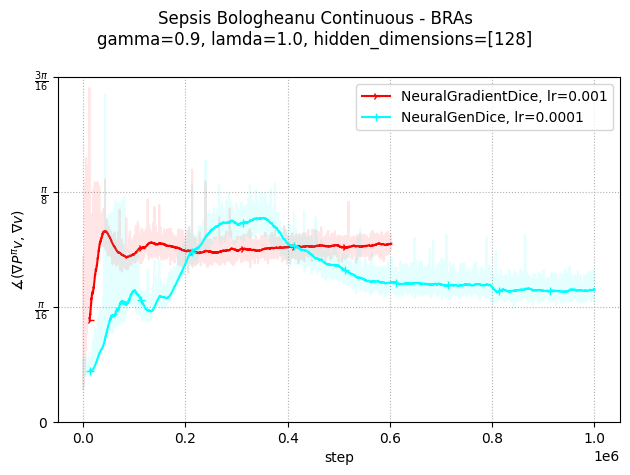

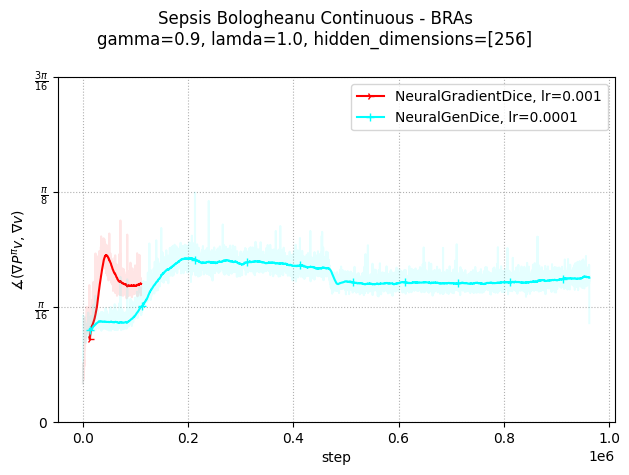

In [18]:
def plot_bras(hyperparameters_list, dir=None):

    plt.figure(tight_layout=True)

    colors = {
        "NeuralDualDice": "green",
        "NeuralGradientDice": "red",
        "NeuralGenDice": "cyan",
    }
    alpha = 0.1
    markers = {
        "NeuralDualDice": "3",
        "NeuralGradientDice": "4",
        "NeuralGenDice": "+",
    }
    markevery = 1_000

    for hyperparameters in hyperparameters_list:
        name = hyperparameters["name"]
        learning_rate = hyperparameters["learning_rate"]

        id_evaluation = json_get_id(
            file_path=os.path.join(dir_dataset["continuous"]["neural"], "evaluation.json"),
            dictionary=hyperparameters
        )

        log = get_log(
            log_dir=os.path.join(dir_dataset["continuous"]["neural"], id_evaluation), ) # type: ignore

        x = np.array(log["data"]["cos_angle"]["steps"])
        y = np.array(log["data"]["cos_angle"]["values"])
        y = np.arccos(y)

        x_ma = x[n_ma-1:]
        y_ma = moving_average_N(y, n_ma)

        label = f"{name}, lr={learning_rate}"

        plt.plot(x, y, color=colors[name], alpha=alpha)
        plt.plot(x_ma, y_ma, color=colors[name], label=label, alpha=1, marker=markers[name], markevery=markevery)

    plt.grid(linestyle=":")
    plt.legend()

    plt.xlabel("step")
    plt.ylabel(r"$\measuredangle ( \nabla P^\pi v, \nabla v )$")

    stop = 4/16 * np.pi; step = 1/16 * np.pi
    pi_ticks = np.arange(0, stop, step)
    pi_labels = [r"$0$", r"$\frac{\pi}{16}$", r"$\frac{\pi}{8}$", r"$\frac{3 \pi}{16}$"]
    plt.yticks(pi_ticks, pi_labels)

    plt.ylim([0, stop-step])

    hyperparameters = random.choice(hyperparameters_list)
    gamma = hyperparameters["gamma"]
    hidden_dimensions = hyperparameters["hidden_dimensions"]
    suptitle = "Sepsis Bologheanu Continuous - BRAs" + "\n" + f"gamma={gamma}, lamda=1.0, hidden_dimensions={hidden_dimensions}"
    plt.suptitle(suptitle)

    if dir is not None:
        file_name = suptitle.replace("\n", "; ")
        plt.savefig( os.path.join(dir, f"{file_name}.png") )

    plt.show()

for hidden_dimensions in hidden_dimensionss:
    plot_bras(
        hyperparameters_list=[
            {
                "name": name,
                "gamma": gamma,
                "seed": seed,
                "batch_size": batch_size,
                "learning_rate": lrs[name],
                "hidden_dimensions": hidden_dimensions,
                "other": others[name],
            }
                for name in names
        ],
        dir=os.path.join(dir_images, "continuous"),
    )

In [10]:
def get_stats():

    stats_0 = {}

    for name in names:
        stats_1 = []

        for hidden_dimensions, axvspan in zip(hidden_dimensionss, axvspans):
            stats_2 = []

            hyperparameters = {
                "name": name,
                "gamma": gamma,
                "seed": seed,
                "batch_size": batch_size,
                "learning_rate": lrs[name],
                "hidden_dimensions": hidden_dimensions,
                "other": others[name],
            }

            id_evaluation = json_get_id(
                file_path=os.path.join( dir_dataset["continuous"]["neural"], "evaluation.json" ),
                dictionary=hyperparameters
            )

            log = get_log(
                log_dir=os.path.join( dir_dataset["continuous"]["neural"], id_evaluation), ) # type: ignore

            for ws in ["s", "w"]:

                x = np.array(log["data"][f"pv_{ws}"]["steps"])
                y = np.array(log["data"][f"pv_{ws}"]["values"]) / (1 - gamma)

                x_min, x_max = axvspan[name]
                mask = (x_min <= x) * (x <= x_max)

                mean = np.mean(y[mask])
                std  = np.std (y[mask])

                if pd.isna(mean) or pd.isna(std): continue

                stats_2.append( (mean, std) )

            stats_1.append(stats_2)

        stats_0[name] = stats_1

    return stats_0

stats = get_stats()
stats

{'NeuralGradientDice': [[(0.09309514432155187, 0.011514529801511726),
   (0.110170654180207, 0.012096106625550503)],
  [(0.10289181298915027, 0.005503019605252547),
   (0.13248291365775489, 0.008123786586359429)],
  [(0.08124919760572238, 0.006123402082767828),
   (0.1044593886497112, 0.005926970867298317)],
  [(0.10324577314417756, 0.0026038765996951323),
   (0.14774554775128912, 0.003927497616554817)]],
 'NeuralGenDice': [[(0.1534606694047015, 0.013412567530960503),
   (0.20476804158062867, 0.02799611467622054)],
  [(0.14006948999369692, 0.003551876959314286),
   (0.18744069921824374, 0.008596349460449074)],
  [(0.13625600012342834, 0.004245442753534329),
   (0.1765176307938861, 0.007161544621236723)],
  [(0.14444914344246335, 0.023203053610061822),
   (0.20064940298730644, 0.03796356548838024)]]}

In [11]:
def group_barplot(
        group_names, grouped_measurements,
        title=None, suptitle=None, xlabel=None, ylabel=None, ylim=None,
        bar_labels=False, bar_colors=None,
        legend_loc=None, figsize=None, capsize=None, baselines=None,
        dir=None):

    if baselines is None: baselines = []

    # https://matplotlib.org/stable/gallery/lines_bars_and_markers/barchart.html

    plt.figure( layout="constrained", figsize=figsize, )

    max_variants = -float("inf")
    for measurements in grouped_measurements.values():
        for measurement in measurements:
            if ( n_variants := len(measurement) ) > max_variants:
                max_variants = n_variants
    max_variants = int(max_variants)

    ticks_info = {}

    for i_ms, (attribute, measurements) in enumerate( grouped_measurements.items() ):
        for i_v in range(max_variants):

            x_array = []
            y_array = []
            yerr_array = [] if capsize is not None else None

            for i_m, measurement in enumerate(measurements):
                if i_m not in ticks_info.keys(): ticks_info[i_m] = []

                if i_v >= len(measurement): break

                x = 0
                for j_ms, measurements_ in enumerate( grouped_measurements.values() ):
                    if j_ms == 0: x += i_m
                    for j_m, measurement_ in enumerate(measurements_):
                        for j_v, _ in enumerate(measurement_):
                            A = j_m > i_m
                            B = j_m == i_m and j_ms > i_ms
                            C = j_m == i_m and j_ms == i_ms and j_v > i_v
                            if not (A or B or C): x += 1

                ticks_info[i_m].append(x)

                y    = measurement[i_v][0]
                yerr = measurement[i_v][1]

                x_array.append(x)
                y_array.append(y)
                if yerr_array is not None: yerr_array.append(yerr)

            label = attribute if i_v == 0 else None
            color = bar_colors[i_ms] if bar_colors is not None else None

            rects = plt.bar(x_array, y_array, 1, yerr=yerr, capsize=capsize, label=label, color=color)
            if bar_labels: plt.bar_label(rects, padding=3)

    for baseline in baselines:
        plt.axhline(
            y=baseline["y"],
            label=baseline["label"],
            color=baseline["color"],
            marker=baseline["marker"],
            linestyle=baseline["linestyle"],
        )

    plt.xticks([np.mean(v) for v in ticks_info.values()], group_names)
    plt.legend(loc=legend_loc, ncols=3)
    plt.grid(linestyle=":", axis="y")

    if suptitle is not None: plt.suptitle(suptitle)
    if title    is not None: plt.title(title)
    if ylabel   is not None: plt.ylabel(ylabel)
    if xlabel   is not None: plt.xlabel(xlabel)
    if ylim     is not None: plt.ylim(ylim)

    if dir is not None:
        file_name = f"{suptitle}; {title}.png"
        plt.savefig( os.path.join(dir, file_name) )

    plt.show()

In [10]:
dataset["neural"]

,id,t,obs_init,obs,act,rew,obs_next,probs_init,probs,probs_next
0,20,0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",1,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[4.6153204e-07, 0.41843063, 0.09803962, 0.2416..."
1,20,1,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",1,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[4.6153204e-07, 0.41843063, 0.09803962, 0.2416...","[1.3341968e-18, 0.99022615, 0.0011949288, 0.00..."
2,20,2,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",1,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[1.3341968e-18, 0.99022615, 0.0011949288, 0.00...","[4.3437872e-23, 0.99479574, 5.7580583e-06, 0.0..."
3,20,3,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",1,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[4.3437872e-23, 0.99479574, 5.7580583e-06, 0.0...","[9.325621e-10, 0.00401068, 0.008864737, 0.9811..."
4,20,4,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",1,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[9.325621e-10, 0.00401068, 0.008864737, 0.9811...","[4.656923e-15, 6.592461e-05, 0.0002901405, 0.9..."
...,...,...,...,...,...,...,...,...,...,...
14299,23535,3,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",3,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[5.8916213e-19, 1.5590822e-07, 6.9822427e-06, ...","[4.4590848e-10, 4.408491e-09, 0.0012431995, 0...."
14300,23535,4,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",2,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[4.4590848e-10, 4.408491e-09, 0.0012431995, 0....","[6.259185e-07, 1.6154662e-07, 0.01574939, 0.98..."
14301,23535,5,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",2,0.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[6.259185e-07, 1.6154661e-07, 0.015749387, 0.9...","[1.4885999e-09, 6.200223e-07, 0.010555137, 0.9..."
14302,23535,6,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[-0.0800016, -0.08865834, -0.08860586, -0.0254...",2,1.0,"[-0.0800016, -0.08865834, -0.08860586, -0.0254...","[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[1.4885999e-09, 6.200223e-07, 0.010555137, 0.9...","[1.3618055e-17, 1.7175033e-06, 0.6644643, 0.33..."


In [11]:
dataset["tabular"]

,id,t,obs_init,obs,act,rew,obs_next,probs_init,probs,probs_next
0,20,0,58,58,1,0.0,179,"[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[4.6153204e-07, 0.41843063, 0.09803962, 0.2416..."
1,20,1,58,179,1,0.0,17,"[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[4.6153204e-07, 0.41843063, 0.09803962, 0.2416...","[1.3341968e-18, 0.99022615, 0.0011949288, 0.00..."
2,20,2,58,17,1,0.0,17,"[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[1.3341968e-18, 0.99022615, 0.0011949288, 0.00...","[4.3437872e-23, 0.99479574, 5.7580583e-06, 0.0..."
3,20,3,58,17,1,0.0,17,"[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[4.3437872e-23, 0.99479574, 5.7580583e-06, 0.0...","[9.325621e-10, 0.00401068, 0.008864737, 0.9811..."
4,20,4,58,17,1,0.0,17,"[1.9520018e-30, 0.28778797, 0.007400115, 0.701...","[9.325621e-10, 0.00401068, 0.008864737, 0.9811...","[4.656923e-15, 6.592461e-05, 0.0002901405, 0.9..."
...,...,...,...,...,...,...,...,...,...,...
14299,23535,3,114,159,3,0.0,159,"[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[5.8916213e-19, 1.5590822e-07, 6.9822427e-06, ...","[4.4590848e-10, 4.408491e-09, 0.0012431995, 0...."
14300,23535,4,114,159,2,0.0,159,"[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[4.4590848e-10, 4.408491e-09, 0.0012431995, 0....","[6.259185e-07, 1.6154662e-07, 0.01574939, 0.98..."
14301,23535,5,114,159,2,0.0,159,"[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[6.259185e-07, 1.6154661e-07, 0.015749387, 0.9...","[1.4885999e-09, 6.200223e-07, 0.010555137, 0.9..."
14302,23535,6,114,159,2,1.0,257,"[6.0926306e-25, 5.672189e-07, 8.905808e-06, 0....","[1.4885999e-09, 6.200223e-07, 0.010555137, 0.9...","[1.3618055e-17, 1.7175033e-06, 0.6644643, 0.33..."


In [12]:
auxiliary_estimates = AuxiliaryEstimates(
    dataset=dataset["tabular"],
    n_obs=n_obs,
    n_act=n_act,
    path=dir_dataset["continuous"]["tabular"],
    verbosity=1,
)

trying to load auxiliary estimates from data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-01-30T11:50:56.552678
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-01-30T11:50:56.552678/d0_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-01-30T11:50:56.552678/dD_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-01-30T11:50:56.552678/P_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-01-30T11:50:56.552678/r_bar.npy
loaded data/sepsis/bologheanu/2025-01-30T11:42:45.694984/2025-01-30T12:01:58.273325/2025-01-30T11:50:56.552678/n.npy


In [13]:
estimators["evaluation"] = {} # type: ignore

for estimator_type in [
    TabularVafe, TabularDice, TabularDualDice, TabularGradientDice, ]:

    estimator = estimator_type(
        dataset,
        n_obs,
        n_act,
        dir_dataset["continuous"]["tabular"],
        verbosity=1,
        auxiliary_estimates=auxiliary_estimates,
    )

    estimators["evaluation"][estimator.__name__] = estimator

In [14]:
pvs_tabular = {}

projected = True
modified = True

for estimator_name, estimator in estimators["evaluation"].items(): # type: ignore

    if estimator_name == "TabularVafe":
        pvs_tabular[estimator_name] = get_pv_s(
            estimator_s=estimator,
            gamma_s=gamma,
            projected=projected, weighted=None,
            modified=modified, lamda=lamda,
        )
    else:
        pvs_tabular[estimator_name] = {
            weighted: get_pv_s(
                estimator_s=estimator,
                gamma_s=gamma,
                projected=projected, weighted=weighted,
                modified=modified, lamda=lamda,
            )
                for weighted in [False, True]
        }

pvs_tabular

{'TabularVafe': 0.01648574051719777,
 'TabularDice': {False: 0.01648574051719777, True: 0.019413438104531052},
 'TabularDualDice': {False: 0.016485740517197332, True: 0.019413438104531194},
 'TabularGradientDice': {False: 0.0028113511963332723,
  True: -0.027389489023661798}}

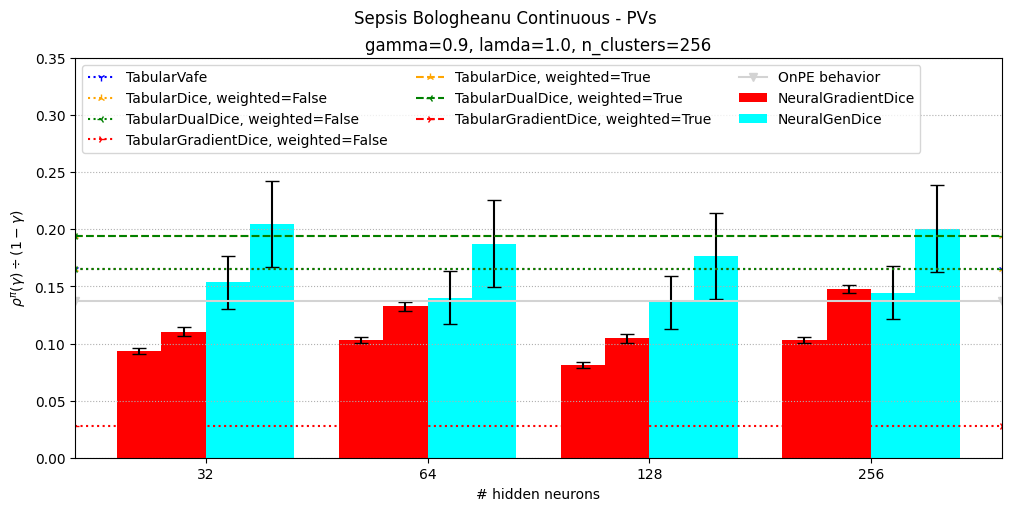

In [15]:
group_barplot(
    group_names=[hidden_dimensions[0] for hidden_dimensions in hidden_dimensionss],
    grouped_measurements = stats,
    suptitle="Sepsis Bologheanu Continuous - PVs",
    title=f"{gamma=}, {lamda=}, n_clusters={n_obs-2}",
    xlabel="# hidden neurons",
    ylabel=latex_labels["pv_scaled"](),
    ylim=(0, 0.35),
    bar_labels=False,
    bar_colors=["red", "cyan"],
    legend_loc="upper left",
    figsize=(10, 5),
    capsize=5,
    baselines=[
        {
            "y": pvs_tabular["TabularVafe"] / (1 - gamma),
            "label": "TabularVafe",
            "color": "blue",
            "marker": "1",
            "linestyle": ":",
        },
        {
            "y": pvs_tabular["TabularDice"][False] / (1 - gamma),
            "label": "TabularDice, weighted=False",
            "color": "orange",
            "marker": "2",
            "linestyle": ":",
        },
        {
            "y": pvs_tabular["TabularDualDice"][False] / (1 - gamma),
            "label": "TabularDualDice, weighted=False",
            "color": "green",
            "marker": "3",
            "linestyle": ":",
        },
        {
            "y": pvs_tabular["TabularGradientDice"][False] / (1 - gamma),
            "label": "TabularGradientDice, weighted=False",
            "color": "red",
            "marker": "4",
            "linestyle": ":",
        },
        {
            "y": pvs_tabular["TabularDice"][True] / (1 - gamma),
            "label": "TabularDice, weighted=True",
            "color": "orange",
            "marker": "2",
            "linestyle": "--",
        },
        {
            "y": pvs_tabular["TabularDualDice"][True] / (1 - gamma),
            "label": "TabularDualDice, weighted=True",
            "color": "green",
            "marker": "3",
            "linestyle": "--",
        },
        {
            "y": pvs_tabular["TabularGradientDice"][True] / (1 - gamma),
            "label": "TabularGradientDice, weighted=True",
            "color": "red",
            "marker": "4",
            "linestyle": "--",
        },
        {
            "y": get_policy_value["behavior"](gamma, scale=False),
            "label": "OnPE behavior",
            "color": "lightgrey",
            "marker": "v",
            "linestyle": "-",
        },
    ],
    dir=os.path.join(dir_images, "continuous"),
)

# All Plots

In [19]:
hidden_dimensions_ = [128,]

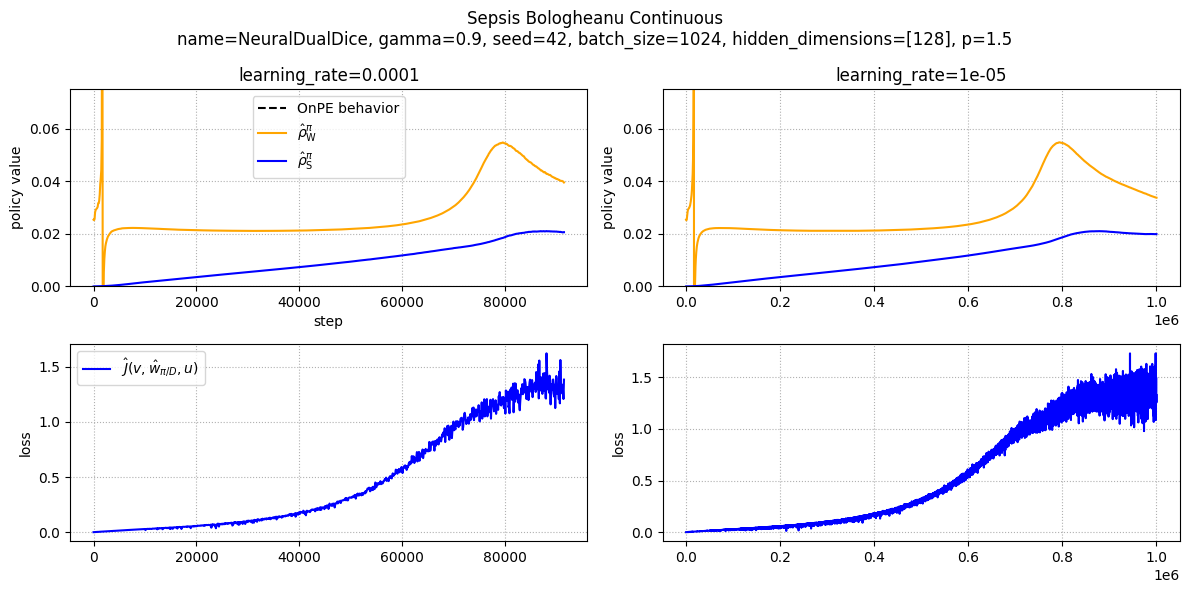

In [22]:
get_logs_and_plot(
    get_policy_value=get_policy_value,
    hyperparameters_evaluation=[
        {
            "name": "NeuralDualDice",
            "gamma": gamma,
            "seed": seed,
            "batch_size": batch_size,
            "learning_rate": learning_rate_,
            "hidden_dimensions": hidden_dimensions_,
            "other": {
                "p": p,
            },
        }
            for learning_rate_ in [1e-4, 1e-5]
    ],
    hyperparameters_dict={
        "split": {
            "seed": seed,
            "ratios": {
                "train": 0.4,
                "validation": 0.1,
                "test": 0.5,
            },
        },
        "policy": {
            "n_neurons": 1024,
            "learning_rate": 1e-4,
            "batch_size": 512,
            "gamma": 0.99,
        },
    },
    ylims=2*[
        { "pv": (0, 0.075), }
    ],
    dir_save=os.path.join(dir_images, "continuous"),
)

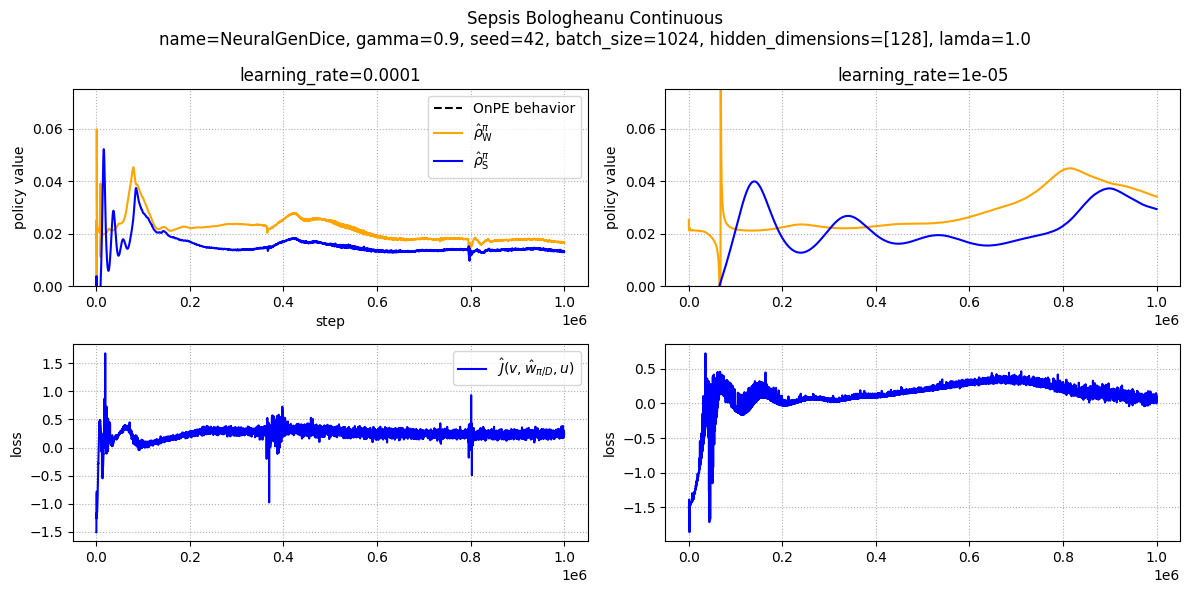

In [23]:
get_logs_and_plot(
    get_policy_value=get_policy_value,
    hyperparameters_evaluation=[
        {
            "name": "NeuralGenDice",
            "gamma": gamma,
            "seed": seed,
            "batch_size": batch_size,
            "learning_rate": learning_rate_,
            "hidden_dimensions": hidden_dimensions_,
            "other": {
                "lamda": 1.0,
            },
        }
            for learning_rate_ in [1e-4, 1e-5]
    ],
    hyperparameters_dict={
        "split": {
            "seed": seed,
            "ratios": {
                "train": 0.4,
                "validation": 0.1,
                "test": 0.5,
            },
        },
        "policy": {
            "n_neurons": 1024,
            "learning_rate": 1e-4,
            "batch_size": 512,
            "gamma": 0.99,
        },
    },
    ylims=2*[
        { "pv": (0, 0.075), }
    ],
    dir_save=os.path.join(dir_images, "continuous"),
)

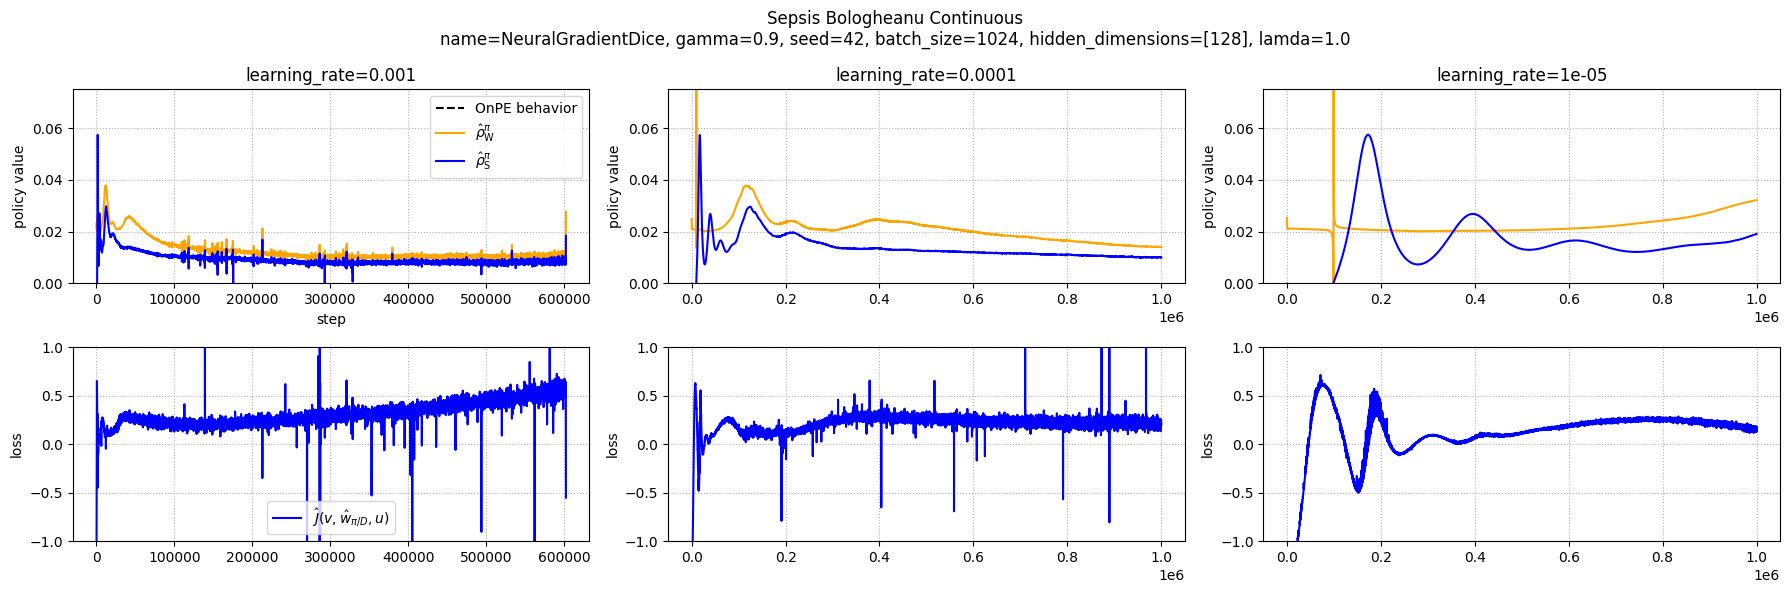

In [24]:
get_logs_and_plot(
    get_policy_value=get_policy_value,
    hyperparameters_evaluation=[
        {
            "name": "NeuralGradientDice",
            "gamma": gamma,
            "seed": seed,
            "batch_size": batch_size,
            "learning_rate": learning_rate_,
            "hidden_dimensions": hidden_dimensions_,
            "other": {
                "lamda": 1.0,
            },
        }
            for learning_rate_ in [1e-3, 1e-4, 1e-5]
    ],
    hyperparameters_dict={
        "split": {
            "seed": seed,
            "ratios": {
                "train": 0.4,
                "validation": 0.1,
                "test": 0.5,
            },
        },
        "policy": {
            "n_neurons": 1024,
            "learning_rate": 1e-4,
            "batch_size": 512,
            "gamma": 0.99,
        },
    },
    ylims=3*[
        { "pv": (0, 0.075), "loss": (-1, 1), }
    ],
    dir_save=os.path.join(dir_images, "continuous"),
)